In [2]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image 
# import cv2

In [3]:
# Paths 
PROJECT_ROOT = Path.cwd().parent
TRAIN_DIR = PROJECT_ROOT/"data"/ "raw" /"train"
TEST_DIR = PROJECT_ROOT/"data"/ "raw" /"test"

print(TRAIN_DIR)
print(TEST_DIR)

g:\Project\RTED\data\raw\train
g:\Project\RTED\data\raw\test


In [4]:
classes = sorted(os.listdir(TRAIN_DIR))
print(classes)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [5]:
# Number or Images in each folder
class_counts = {}

for emotion in os.listdir("../data/raw/train"):
    class_counts[emotion]= len(os.listdir(f"../data/raw/train/{emotion}"))

df_counts = pd.DataFrame(
    class_counts.items(),
    columns=["Emotion","Count"])
df_counts

,Emotion,Count
0,angry,3995
1,disgust,436
2,fear,4097
3,happy,7215
4,neutral,4965
5,sad,4830
6,surprise,3171


### Plot the distribution

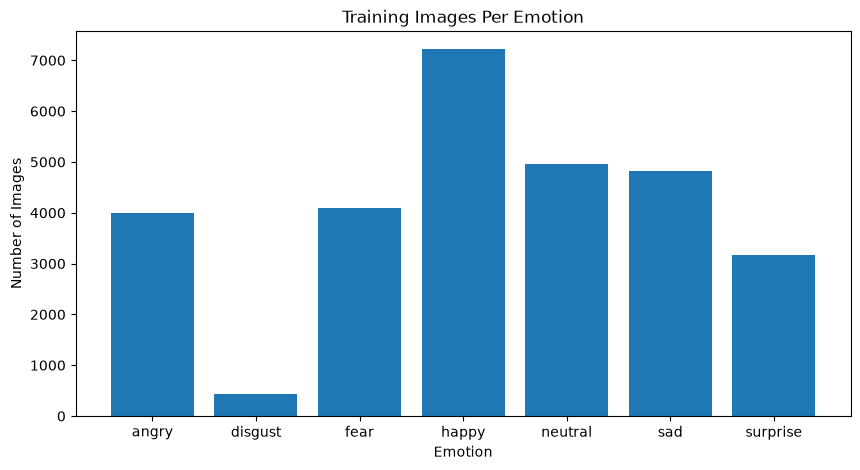

In [6]:
plt.figure(figsize=(10,5))
plt.bar(
    df_counts['Emotion'],
    df_counts['Count']
)
plt.title("Training Images Per Emotion")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.show()

There is an imbalance in data. So we need data augmentation.


### Visual sample images

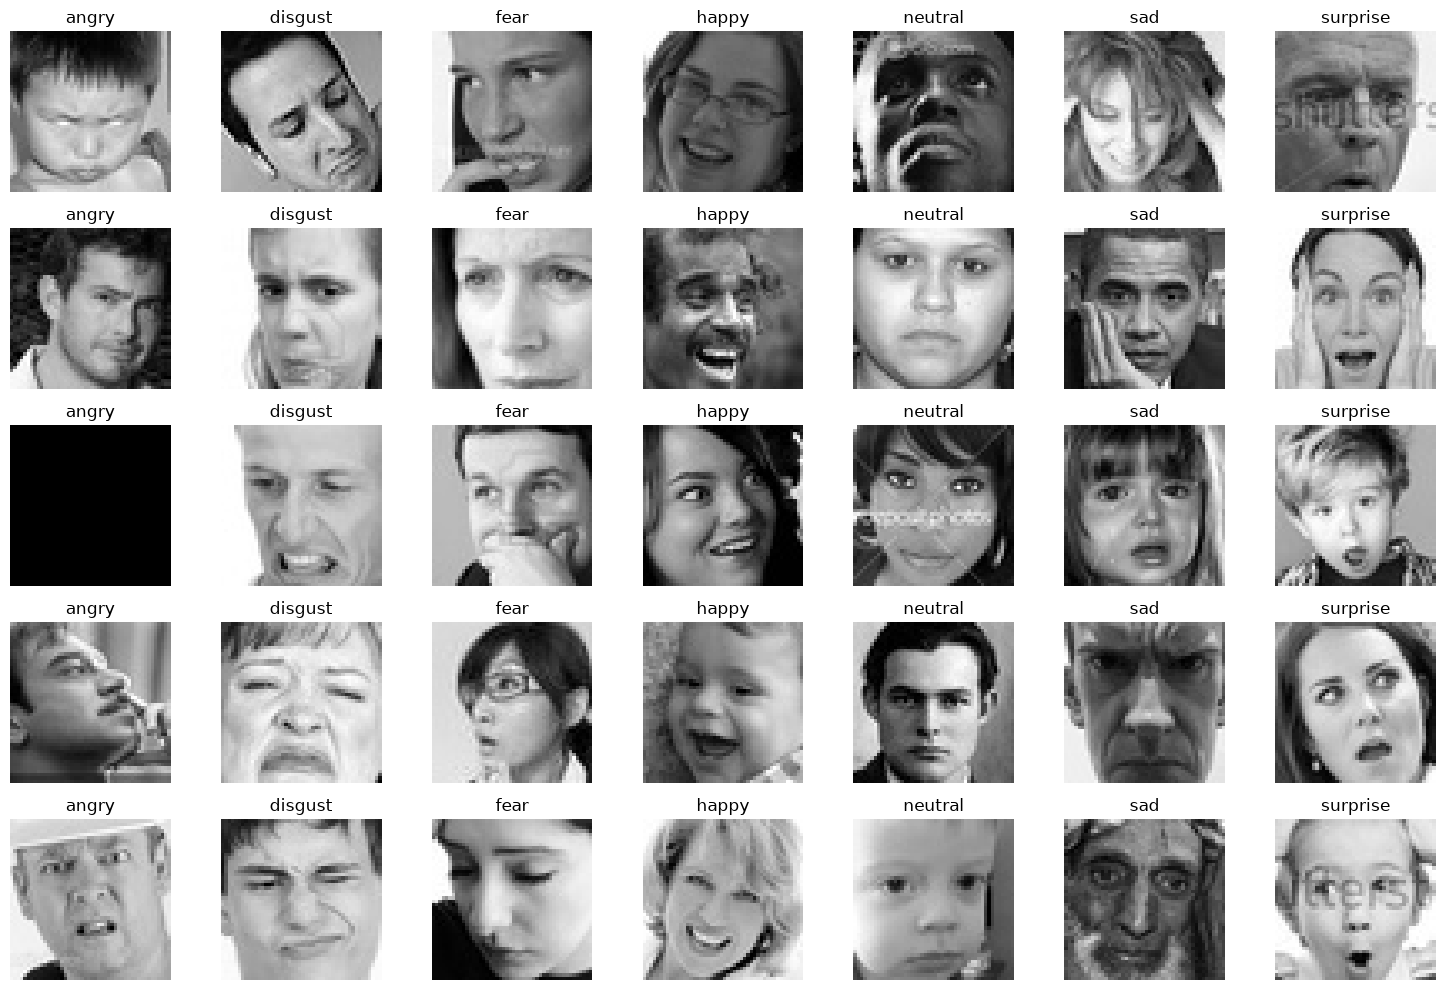

g:\Project\RTED\data\raw\train\surprise\Training_10073433.jpg


In [7]:
fig,axes = plt.subplots(
    5,len(df_counts['Emotion']),
    figsize=(15,10)
)

for col,emotion in enumerate(classes):
    image_list = os.listdir(TRAIN_DIR / emotion)
    for row in range(5):
        img_path = TRAIN_DIR/emotion/image_list[row]
        img= Image.open(img_path)

        axes[row,col].imshow(img,cmap = 'gray')
        axes[row,col].set_title(emotion)
        axes[row,col].axis("off")
plt.tight_layout()
plt.show()
print(img_path)


##### Fear and surprise emotions appears visually similar

In [8]:
# Iamge size 
print(f"Image Size :  {img.size}")

# Type of Image 
print(f"Type of Image: {img.mode}")

Image Size :  (48, 48)
Type of Image: L


### Convert the image to numbers

In [9]:
image_array = np.array(img)
print("Image as an Array : ",image_array)

# shape
print("Shape of the Image: ",image_array.shape)

Image as an Array :  [[209 217 221 ... 232 228 223]
 [212 214 221 ... 232 235 228]
 [217 218 223 ... 230 235 230]
 ...
 [238 210 205 ... 242 244 238]
 [128 171 160 ... 190 137 104]
 [ 72  73 147 ...  80  59  68]]
Shape of the Image:  (48, 48)


In [10]:
image_array.mean()

np.float64(183.85850694444446)

### Image validation

In [11]:
corrupt_images =[]
for emotion in classes:
    img_paths = os.listdir(TRAIN_DIR/emotion)
    for img_name in img_paths:
        try:
            Image.open(TRAIN_DIR/emotion/img_name).verify()
        except Exception:
            corrupt_images.append((img_path,emotion))


In [12]:
len(corrupt_images)

0

In [13]:
print("=" * 40)
print("DATASET SUMMARY")
print("=" * 40)

print(f"Number of Classes : {len(classes)}")
print(f"Total Images      : {df_counts.sum()}")
print(f"Image Size        : {set(img.size)}")
print(f"Image Mode        : {set(img.mode)}")
print(f"Corrupted Images  : {len(corrupt_images)}")

DATASET SUMMARY
Number of Classes : 7
Total Images      : Emotion    angrydisgustfearhappyneutralsadsurprise
Count                                        28709
dtype: object
Image Size        : {48}
Image Mode        : {'L'}
Corrupted Images  : 0


### Average Image Per Emotion

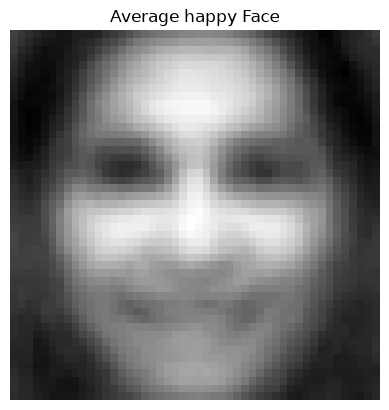

In [14]:
emotion = "happy"

images = []

for file in os.listdir(TRAIN_DIR / emotion)[:500]:

    img = Image.open(TRAIN_DIR/emotion/file).convert("L")
    img=np.array(img)

    images.append(img)

avg_img = np.mean(images, axis=0)

plt.imshow(avg_img, cmap="gray")
plt.title(f"Average {emotion} Face")
plt.axis("off")
plt.show()